# TCAV Refactored Workflow
This notebook mirrors the original `tcav.ipynb` logic but delegates each stage to the new `src/` modules.
Run it end-to-end to validate the modular pipeline or use individual sections during experimentation.

In [ ]:
# !uv pip install --upgrade pip setuptools wheel
# !uv pip install git+https://github.com/automl/Drift-Resilient_TabPFN.git
# !uv pip install "numpy<2.0.0"

Using Python 3.10.19 environment at: /home/rafael-martins-gomes/Desktop/others/TCAV/.venv
Resolved 3 packages in 46ms                                          
Prepared 3 packages in 0.21ms                                            
Installed 3 packages in 7ms                                 
 + pip==25.3
 + setuptools==80.9.0
 + wheel==0.45.1
Using Python 3.10.19 environment at: /home/rafael-martins-gomes/Desktop/others/TCAV/.venv
Resolved 134 packages in 2.14s                                       
⠙ Preparing packages... (0/41)                                                  
⠙ Preparing packages... (0/41)------------------     0 B/381.37 KiB          
⠙ Preparing packages... (0/41)------------------     0 B/381.37 KiB          
wrapt                ------------------------------     0 B/111.02 KiB
⠙ Preparing packages... (0/41)------------------     0 B/381.37 KiB          
wrapt                ------------------------------     0 B/111.02 KiB
⠙ Preparing packages... (0/41)------

In [ ]:
# username = "automl"
# repo = "Drift-Resilient_TabPFN"

# # Uninstall pre-installed torch, torchaudio, torchvision, and torchtext to
# # prevent conflicts
# # !pip uninstall -y torch torchaudio torchvision torchtext numpy tsfresh transformers sentence-transformers peft
# # Clone our Package, including code to run the experiments.
# !uv pip install git+https://github.com/{username}/{repo}.git

# # Due to a numpy revert to <2.0.0 we have to restart the runtime before we move on
# # See https://github.com/googlecolab/colabtools/issues/5238
# # print('Stopping runtime due to numpy downgrade!')
# # import os
# # os.kill(os.getpid(), 9)

Using Python 3.11.14 environment at: /home/rafael-martins-gomes/Desktop/others/TCAV/.venv
Resolved 132 packages in 1.82s                                       
Audited 132 packages in 2ms


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data.ingestion import load_free_light_chain_dataset, summarize_dataset
from src.data.preprocessing import build_feature_matrix, temporal_split, normalize_features
from src.modeling.tabpfn_loader import load_tabpfn_model
from src.modeling.tabpfn_trainer import fit_with_drift
from src.modeling.inference import batched_predict_proba, evaluate_predictions, per_year_metrics
from src.embeddings.extractor import extract_embeddings_robust
from src.embeddings.clustering import kernel_kmeans_on_embeddings
from src.concepts import train_cavs, compute_model_probabilities, train_surrogate, compute_tcav
from src.reporting import tcav_results_to_frame, plot_tcav_bar, plot_tcav_histograms

In [2]:
import tabpfn
print(tabpfn.__file__)

/home/rafael-martins-gomes/Desktop/others/TCAV/.venv/lib/python3.10/site-packages/tabpfn/__init__.py


## 1. Load and summarize the dataset

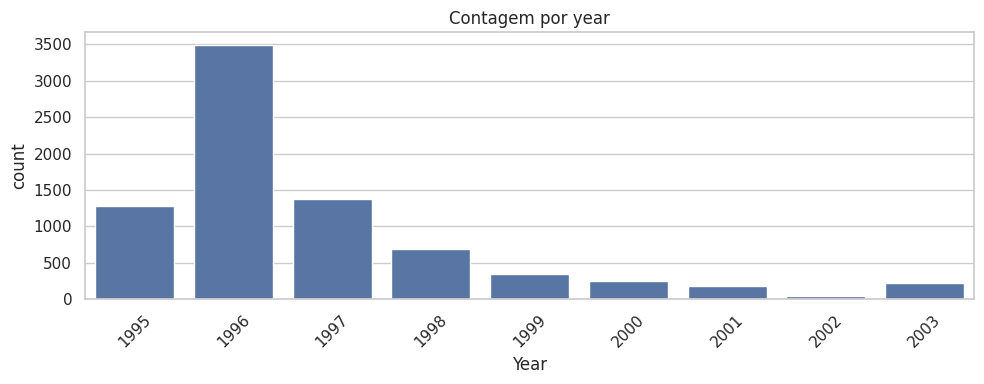

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


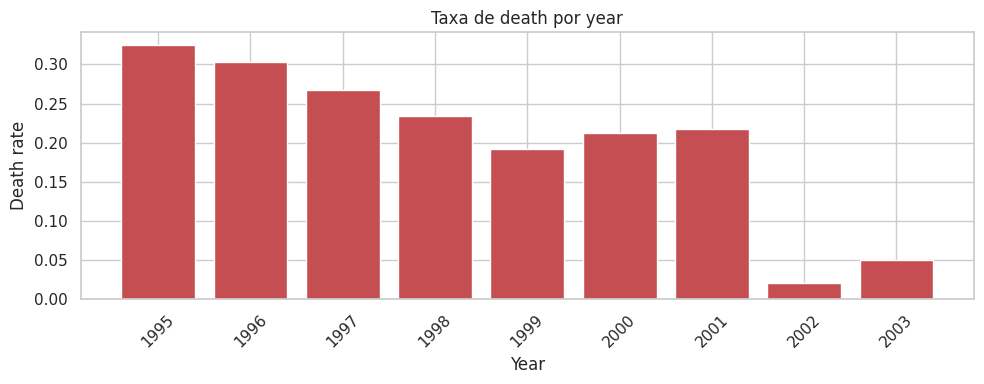

DatasetSummary(shape=(7874, 12), columns=['Unnamed: 0', 'age', 'sex', 'year', 'kappa', 'lambda', 'flc.grp', 'creatinine', 'mgus', 'futime', 'death', 'chapter'], missing_per_column=Unnamed: 0       0
age              0
sex              0
year             0
kappa            0
lambda           0
flc.grp          0
creatinine    1350
mgus             0
futime           0
death            0
chapter       5705
dtype: int64, numeric_description=             count         mean          std     min      25%     50%  \
Unnamed: 0  7874.0       3937.5  2273.172343     1.0  1969.25  3937.5   
age         7874.0    64.293117    10.462719    50.0     55.0    63.0   
year        7874.0  1996.790831     1.765156  1995.0   1996.0  1996.0   
kappa       7874.0     1.430881     0.896774    0.01     0.96    1.27   
lambda      7874.0     1.702624     1.030732    0.04      1.2    1.51   
flc.grp     7874.0     5.470536     2.863011     1.0      3.0     5.0   
creatinine  6524.0     1.093516     0.416507   

In [3]:
df = load_free_light_chain_dataset()
summary = summarize_dataset(df, show_plots=True)
summary

## 2. Preprocess and split

In [4]:
pre = build_feature_matrix(df)
split = temporal_split(pre.feature_frame, pre.target, pre.years)
normalized = normalize_features(split)
normalized

NormalizedData(X_train=      sex_bin       age     kappa    lambda   flc.grp  creatinine      mgus  \
0    -0.89375  3.081653  4.740200  3.035504  1.590445    1.603932 -0.125392   
1    -0.89375  2.606554 -0.610201 -0.978244 -1.545188   -0.458975 -0.125392   
2    -0.89375  2.796593  3.255824  2.064978  1.590445    0.830342 -0.125392   
3    -0.89375  2.606554  1.106802  0.498684  1.242041   -0.201112 -0.125392   
4    -0.89375  2.701574 -0.111716 -0.010602  0.196830    0.056751 -0.125392   
...       ...       ...       ...       ...       ...         ...       ...   
7424 -0.89375 -1.194239 -0.703251 -0.644806 -1.196785   -0.974702 -0.125392   
7425 -0.89375 -1.194239 -0.233568 -0.087475  0.196830   -0.201112 -0.125392   
7426 -0.89375 -1.194239 -0.623494 -1.076258 -1.545188   -0.716839 -0.125392   
7427 -0.89375 -1.099219  0.320304  0.950315  1.242041   -0.201112 -0.125392   
7428 -0.89375 -1.384278 -0.255723 -0.433405 -0.499977   -0.974702 -0.125392   

        futime  
0    -2.577

## 3. Train TabPFN with drift tokens

In [5]:
model = load_tabpfn_model()
dist_train = pre.years[: normalized.X_train.shape[0]]  # placeholder mapping
dist_train = split.year_to_domain
dist_train_vec = normalized.X_train.index.to_series().map(lambda idx: split.year_to_domain[int(split.years_train[idx])]).to_numpy()
model, fit_artifacts = fit_with_drift(model, normalized.X_train.to_numpy(dtype='float32'), split.y_train, dist_train_vec)
fit_artifacts

Loading TabPFN model using best_dist configuration.
Initialized decoder for standard with (None, 10)  and nout 10


{'run_id': 'tabpfn_temporal_fit_free_light_chain',
 'fit_time': 0.0867803310002273,
 'additional_x_device': 'cpu',
 'additional_x_shape': (7429, 1, 1)}

## 4. Evaluate

In [ ]:
dist_test_vec = normalized.X_test.index.to_series().map(lambda idx: split.year_to_domain[int(split.years_test[idx])]).to_numpy()
probs = batched_predict_proba(model, normalized.X_test.to_numpy(dtype='float32'), dist_test_vec)
inference = evaluate_predictions(split.y_test, probs)
year_metrics = per_year_metrics(split.years_test, split.y_test, inference.y_pred, inference.probs_pos)
inference, year_metrics.head()

%load_ext autoreload
%autoreload 2
import numpy as np

from src.data.ingestion import load_free_light_chain_dataset, summarize_dataset
from src.data.preprocessing import build_feature_matrix, temporal_split, normalize_features
from src.modeling.tabpfn_loader import load_tabpfn_model
from src.modeling.tabpfn_trainer import fit_with_drift
from src.modeling.inference import batched_predict_proba, evaluate_predictions, per_year_metrics
from src.embeddings.extractor import extract_embeddings_robust
from src.embeddings.clustering import kernel_kmeans_on_embeddings
from src.concepts import train_cavs, compute_model_probabilities, train_surrogate, compute_tcav
from src.reporting import tcav_results_to_frame, plot_tcav_bar, plot_tcav_histograms

## 1. Load & summarize data

In [ ]:
df = load_free_light_chain_dataset()
dataset_summary = summarize_dataset(df, show_plots=True)
dataset_summary

## 2. Preprocess and temporal split

In [ ]:
pre = build_feature_matrix(df)
split = temporal_split(pre.feature_frame, pre.target, pre.years)
normalized = normalize_features(split)
normalized

## 3. Train TabPFN with drift indicators

In [ ]:
X_train_np = normalized.X_train.to_numpy(dtype=np.float32)
X_test_np = normalized.X_test.to_numpy(dtype=np.float32)
dist_train = np.array([split.year_to_domain[int(y)] for y in split.years_train], dtype=np.int64)
dist_test = np.array([split.year_to_domain[int(y)] for y in split.years_test], dtype=np.int64)
model = load_tabpfn_model()
model, fit_artifacts = fit_with_drift(model, X_train_np, split.y_train, dist_train)
fit_artifacts

## 4. Evaluate on held-out years

In [ ]:
probs = batched_predict_proba(model, X_test_np, dist_test)
inference = evaluate_predictions(split.y_test, probs)
year_metrics = per_year_metrics(split.years_test, split.y_test, inference.y_pred, inference.probs_pos)
display(inference.metrics)
year_metrics.head()

## 5. Embeddings, clustering, CAVs, surrogate

In [ ]:
train_emb = extract_embeddings_robust(model, X_train_np, split.years_train, split.year_to_domain)
test_emb = extract_embeddings_robust(model, X_test_np, split.years_test, split.year_to_domain)
clusters = kernel_kmeans_on_embeddings(train_emb.flat)
cavs = train_cavs(train_emb.flat, clusters.labels, clusters.centroids)
p0_train = compute_model_probabilities(model, X_train_np, split.years_train, split.year_to_domain)
surrogate = train_surrogate(train_emb.flat, p0_train)
surrogate

## 6. TCAV scoring & plots

In [ ]:
tcav_results = compute_tcav(cavs, test_emb.flat, surrogate)
tcav_df = tcav_results_to_frame(tcav_results, cavs)
display(tcav_df.head())
plot_tcav_bar(tcav_results)
plot_tcav_histograms(tcav_results)